In [48]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# LaTeX-like math rendering for plots.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# Functions 

### Kets and Projectors handling

In [49]:


SQRT2 = np.sqrt(2.0)

# Single-qubit polarization kets in the H/V computational basis.
POLARIZATION_KETS: dict[str, np.ndarray] = {
    "H": np.array([1.0, 0.0], dtype=complex),
    "V": np.array([0.0, 1.0], dtype=complex),
    "D": np.array([1.0, 1.0], dtype=complex) / SQRT2,
    "A": np.array([1.0, -1.0], dtype=complex) / SQRT2,
    "R": np.array([1.0, 1.0j], dtype=complex) / SQRT2,
    "L": np.array([1.0, -1.0j], dtype=complex) / SQRT2,
}

# Fixed order of the measured two-photon projectors. This same ordering is used
# for POVMs, count vectors, and the linear inversion equations.
MEASUREMENT_LABELS = [
    "HH", "HV", "HD", "HL",
    "VH", "VV", "VD", "VL",
    "DH", "DV", "DD", "DR",
    "RH", "RV", "RD", "RL",
]

def string_to_ket(s: str) -> np.ndarray:
    """Convert a label such as 'HD' into the tensor-product ket |H>|D>."""
    ket = POLARIZATION_KETS[s[0]]
    for char in s[1:]:
        ket = np.kron(ket, POLARIZATION_KETS[char])
    return ket

class POVM: # Positive Operator-Valued Measure (generalized way to represent measurements) 
    # NOTE: In this experiment, each POVM is a rank-1 projector corresponding to one of the measured polarization kets. We use POVM bc it's cool.
    """Rank-1 projector associated with one measured polarization ket."""
    def __init__(self, name: str, ket: np.ndarray):
        """Store the ket and build the projector |ket><ket|."""
        self.name = name
        self.ket = ket
        self.projector = np.outer(ket, ket.conj())
        # Filled by get_counts after the histogram peak has been integrated.
        self.count = None
        self.counts = None
        self.count_std = None
        self.peak = None

    def __repr__(self) -> str:
        """Compact display in notebook outputs."""
        return f"POVM({self.name!r})"

# Define the POVMs for the Bell states and the laser state
PHI_PLUS = POVM("Phi+", (string_to_ket("HH") + string_to_ket("VV")) / SQRT2)
PHI_MINUS = POVM("Phi-", (string_to_ket("HH") - string_to_ket("VV")) / SQRT2)
PSI_PLUS = POVM("Psi+", (string_to_ket("HV") + string_to_ket("VH")) / SQRT2)
PSI_MINUS = POVM("Psi-", (string_to_ket("HV") - string_to_ket("VH")) / SQRT2)
LASER = POVM("LASER", string_to_ket("HH"))     

### Data handling functions

In [50]:
#class Experiment:
#    def __init__(self, name: str, povms: list[POVM], counts: np.ndarray):
#        self.name = name
#        self.povms = povms
#        self.counts = counts

def get_povms(data_path: Path, labels: list[str] = MEASUREMENT_LABELS) -> list[POVM]:
    """Build one projector object for each requested histogram label."""
    povms = []
    for name in labels:
        file = data_path / f"{name}.txt"
        if not file.exists():
            raise FileNotFoundError(file)
        povms.append(POVM(name, string_to_ket(name)))
    return povms


def read_histogram(file: Path) -> tuple[np.ndarray, np.ndarray]: 
    """Read one two-column file as delay times and counts-per-bin."""
    table = np.genfromtxt(file, skip_header=1)
    if table.ndim == 1:
        table = table[None, :]
    return table[:, 0], table[:, 1]


def integrate_highest_peak(
    file: Path,
    *,
    guard_bins: int = 10, # bins to exclude around the peak for background estimation
    sigma: float = 3.0, 
    min_fraction_of_peak: float = 0.0,
) -> dict:
    """Integrate the statistically significant bins around the dominant peak.

    The maximum bin locates the physical coincidence peak, whose delay can move
    between files because of optical-path differences. The background is estimated
    from bins outside a guard region around the maximum; bins contiguous with the
    maximum are integrated while they remain above a Poisson-like threshold.
    """
    delays, bin_counts = read_histogram(file)
    # The optical delay is not assumed fixed (different optical paths due to difference in bulky setup, 
    # diffuse gaussian mode, fiber optic induced phase); use the largest bin in this file.
    peak_index = int(np.argmax(bin_counts))
    peak_count = float(bin_counts[peak_index])

    if peak_count <= 0: # if there is no signal just return no counts
        return {
            "count": 0.0,
            "std": 1.0,
            "raw_count": 0.0,
            "background_per_bin": 0.0,
            "start_time": float(delays[peak_index]),
            "end_time": float(delays[peak_index]),
            "peak_time": float(delays[peak_index]),
            "peak_count": peak_count,
            "bins": 0,
            "threshold": 0.0,
        }

    # Exclude bins near the peak when estimating accidental/background counts.
    background_mask = np.ones(len(bin_counts), dtype=bool)
    background_mask[max(0, peak_index - guard_bins): peak_index + guard_bins + 1] = False
    background_bins = bin_counts[background_mask] 

    # Median is robust against isolated tail spikes and small secondary bumps.
    background = float(np.median(background_bins)) if len(background_bins) else 0.0
    # For Poisson data, sigma_bin approximately sqrt(mean bin count).
    background_noise = np.sqrt(max(background, 1.0))
    # A bin is signal-like if it is sigma standard deviations above background.
    threshold = background + sigma * background_noise
    if min_fraction_of_peak > 0: 
        threshold = max(threshold, min_fraction_of_peak * peak_count)

    # Walk outward from the maximum; this keeps only the connected dominant peak.
    left = peak_index
    while left > 0 and bin_counts[left - 1] >= threshold: # 
        left -= 1

    right = peak_index
    while right + 1 < len(bin_counts) and bin_counts[right + 1] >= threshold:
        right += 1

    n_peak_bins = right - left + 1
    raw_count = float(np.sum(bin_counts[left: right + 1]))
    # Subtract the expected accidental background inside the chosen peak window.
    count = max(0.0, raw_count - n_peak_bins * background)

    n_background_bins = max(1, len(background_bins))
    # Uncertainty combines Poisson shot noise in the peak window plus a small
    # contribution from estimating the background level from finite side bins.
    background_variance = n_peak_bins**2 * max(background, 1.0) / n_background_bins
    std = float(np.sqrt(raw_count + background_variance))

    return {
        "count": count,
        "std": std,
        "raw_count": raw_count,
        "background_per_bin": background,
        "start_time": float(delays[left]),
        "end_time": float(delays[right]),
        "peak_time": float(delays[peak_index]),
        "peak_count": peak_count,
        "bins": int(n_peak_bins),
        "threshold": float(threshold),
    }


def get_counts(povms: list[POVM], data_path: Path, return_details: bool = False):
    """Integrate all histograms and attach the resulting counts to each POVM."""
    counts = []
    details = []
    for povm in povms:
        file = data_path / f"{povm.name}.txt"
        peak = integrate_highest_peak(file)
        povm.count = peak["count"] # this 
        povm.counts = peak["count"]
        povm.count_std = peak["std"]
        povm.peak = peak
        counts.append(peak["count"])
        details.append({"label": povm.name, **peak})

    counts = np.array(counts)
    if return_details:
        return counts, details
    return counts

### Density matrix reconstruction

In [51]:
def naive_density_matrix(povms: list[POVM], normalization_labels=("HH", "HV", "VH", "VV")) -> np.ndarray:
    """Reconstruct rho by linear inversion, without positivity constraints.

    Measurements give probabilities p_i = counts_i / N, with
    p_i = Tr(M_i rho). If rho is expanded in the measured projector basis as
    rho = sum_j c_j M_j, then p_i = sum_j G_ij c_j, where
    G_ij = Tr(M_i^dagger M_j) is the Gram matrix. Solving G c = p gives the
    dual-basis coefficients c_j. This is the naive linear-inversion estimator:
    it fits the measured probabilities but does not enforce rho >= 0.
    """
    counts_by_name = {povm.name: povm.counts for povm in povms}
    missing = [name for name in normalization_labels if counts_by_name.get(name) is None]
    if missing:
        raise ValueError(f"Missing counts for normalization labels: {missing}")

    # Normalization from one complete H/V analyzer setting.
    N = sum(counts_by_name[name] for name in normalization_labels)
    if N <= 0:
        raise ValueError("Normalization count N must be positive.")

    # M_i are rank-1 projectors. They span the 4x4 operator space, but they are
    # not orthogonal to one another, so coefficients are not just probabilities.
    projectors = np.array([povm.projector for povm in povms])
    probabilities = np.array([povm.counts / N for povm in povms], dtype=float)

    # The Gram matrix encodes overlaps between measurement operators:
    # G_ij = <M_i, M_j> = Tr(M_i^dagger M_j).
    gram = np.array(
        [[np.trace(A.conj().T @ B) for B in projectors] for A in projectors],
        dtype=complex,
    )
    # Solve p = G c for the expansion coefficients c_j.
    coefficients = np.linalg.solve(gram, probabilities)

    # Reassemble rho = sum_j c_j M_j. Symmetrization removes tiny numerical
    # anti-Hermitian roundoff, not physical negative eigenvalues.
    rho = np.tensordot(coefficients, projectors, axes=(0, 0))
    return (rho + rho.conj().T) / 2 # ensure hermiticity


### Metrics

In [52]:
def trace_rho(rho: np.ndarray):
    """Return Tr(rho), useful for checking normalization."""
    return np.real_if_close(np.trace(rho))


def trace_rho_squared(rho: np.ndarray):
    """Return Tr(rho^2), equal to purity only for a physical normalized rho."""
    return np.real_if_close(np.trace(rho @ rho))


def fidelity(rho: np.ndarray, target) -> float:
    """Compute overlap with a pure target ket/projector or a density matrix."""
    if isinstance(target, POVM):
        ket = target.ket
        return float(np.real_if_close(np.vdot(ket, rho @ ket)))

    target = np.asarray(target, dtype=complex)
    if target.ndim == 1:
        return float(np.real_if_close(np.vdot(target, rho @ target)))
    return float(np.real_if_close(np.trace(rho @ target)))


def concurrence(rho: np.ndarray) -> float:
    """Two-qubit Wootters concurrence, used here as a diagnostic for rho."""
    sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
    yy = np.kron(sy, sy)
    # Spin-flipped matrix: (sigma_y tensor sigma_y) rho* (sigma_y tensor sigma_y).
    spin_flipped = yy @ rho.conj() @ yy
    evals = np.linalg.eigvals(rho @ spin_flipped)
    roots = np.sqrt(np.clip(np.real(evals), 0.0, None))
    roots = np.sort(roots)[::-1]
    return float(max(0.0, roots[0] - roots[1] - roots[2] - roots[3]))


def partial_transpose_second_qubit(rho: np.ndarray) -> np.ndarray:
    """Partial transpose with respect to the second qubit in HH,HV,VH,VV order."""
    return rho.reshape(2, 2, 2, 2).swapaxes(1, 3).reshape(4, 4)


def negativity(rho: np.ndarray) -> float:
    """Sum the absolute values of negative eigenvalues of the partial transpose."""
    evals = np.linalg.eigvalsh(partial_transpose_second_qubit(rho))
    return float(np.sum(np.abs(evals[evals < 0])))


def entanglement_of_formation(rho: np.ndarray) -> float:
    """Convert concurrence to entanglement of formation for a two-qubit state."""
    C = np.clip(concurrence(rho), 0.0, 1.0)
    if C == 0:
        return 0.0
    x = (1 + np.sqrt(1 - C**2)) / 2
    return float(-(x * np.log2(x) + (1 - x) * np.log2(1 - x)))


def density_matrix_metrics(rho: np.ndarray, target=None) -> dict:
    """Collect basic scalar diagnostics for the reconstructed density matrix."""
    if target is None:
        target = PHI_PLUS
    return {
        "tr_rho": trace_rho(rho),
        "tr_rho_squared": trace_rho_squared(rho),
        "fidelity": fidelity(rho, target),
        "concurrence": concurrence(rho),
        "negativity": negativity(rho),
        "entanglement_of_formation": entanglement_of_formation(rho),
        "eigenvalues": np.linalg.eigvalsh(rho),
    }

### Plot helper functions

In [53]:
def _plot_density_matrix_bars(ax, values: np.ndarray, title: str, basis_labels: list[str], zmax: float):
    """Draw one 3D bar plot for either Re(rho) or Im(rho)."""
    n = values.shape[0]
    # One bar is drawn for every matrix element rho_ij.
    x, y = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    heights = values.reshape(-1)
    dx = dy = 0.62

    # Blue/red sign coding is common in density-matrix visualizations.
    colors = np.where(heights >= 0, "tab:blue", "tab:red")
    ax.bar3d(
        x.reshape(-1) - dx / 2,
        y.reshape(-1) - dy / 2,
        np.zeros(n * n),
        dx,
        dy,
        heights,
        color=colors,
        alpha=0.82,
        edgecolor="black",
        linewidth=0.4,
        shade=True,
    )

    ax.set_title(title, pad=12)
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(basis_labels, rotation=35, ha="right")
    ax.set_yticklabels(basis_labels, rotation=-35, ha="left")
    ax.set_xlabel(r"$i$", labelpad=8)
    ax.set_ylabel(r"$j$", labelpad=8)
    ax.set_zlabel(r"$\rho_{ij}$", labelpad=8)
    ax.set_zlim(-zmax, zmax)
    ax.view_init(elev=28, azim=-55)


def plot_density_matrix_3d(
    rho: np.ndarray,
    *,
    basis_labels: list[str] | None = None,
    title: str = r"\rho_{\mathrm{naive}}",
    same_z_scale: bool = False,
):
    """Plot real and imaginary parts of a 4x4 density matrix as 3D bars."""
    if basis_labels is None:
        basis_labels = [r"$|HH\rangle$", r"$|HV\rangle$", r"$|VH\rangle$", r"$|VV\rangle$"]

    # Separate real and imaginary parts, as typically shown in papers.
    real_part = np.real(rho)
    imag_part = np.imag(rho)
    real_zmax = max(float(np.max(np.abs(real_part))), 1e-12)
    imag_zmax = max(float(np.max(np.abs(imag_part))), 1e-12)
    # By default, let Im(rho) use its own scale so small phases remain visible.
    if same_z_scale:
        real_zmax = imag_zmax = max(real_zmax, imag_zmax)

    fig = plt.figure(figsize=(13, 5.6))
    ax_real = fig.add_subplot(1, 2, 1, projection="3d")
    ax_imag = fig.add_subplot(1, 2, 2, projection="3d")

    _plot_density_matrix_bars(ax_real, real_part, rf"$\mathrm{{Re}}({title})$", basis_labels, real_zmax)
    _plot_density_matrix_bars(ax_imag, imag_part, rf"$\mathrm{{Im}}({title})$", basis_labels, imag_zmax)

    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.88, wspace=0.02)
    return fig, (ax_real, ax_imag)


def plot_peak_integration(
    povm: POVM | str,
    data_path: Path,
    ax=None,
    show_tail_zoom: bool = True,
    tail_zoom_quantile: float = 0.99,
    **peak_kwargs,
):
    if data_path is None:
        raise ValueError("data_path must be provided to plot_peak_integration.")
    """Visualize one histogram and shade the exact peak-integration window."""
    name = povm.name if isinstance(povm, POVM) else str(povm)
    file = data_path / f"{name}.txt"

    delays, bin_counts = read_histogram(file)
    peak = integrate_highest_peak(file, **peak_kwargs)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))

    # Extend the shaded region by half a bin on each side so it covers full bins.
    bin_width = float(np.median(np.diff(delays))) if len(delays) > 1 else 1.0
    start = peak["start_time"] - bin_width / 2
    end = peak["end_time"] + bin_width / 2

    ax.plot(delays, bin_counts, marker=".", linewidth=1.0, label="histogram")
    ax.axvspan(start, end, alpha=0.25, color="tab:orange", label="integrated region")
    ax.axhline(peak["threshold"], color="tab:red", linestyle="--", linewidth=1.0, label="threshold")
    ax.axhline(peak["background_per_bin"], color="tab:gray", linestyle=":", linewidth=1.0, label="background")
    ax.axvline(peak["peak_time"], color="black", linewidth=1.0, alpha=0.7, label="highest bin")

    if show_tail_zoom:
        # The inset keeps the full delay axis but clips the y-range to tail scale.
        tail_mask = (delays < peak["start_time"]) | (delays > peak["end_time"])
        tail_counts = bin_counts[tail_mask]
        if len(tail_counts):
            tail_top = 1.25 * float(np.quantile(tail_counts, tail_zoom_quantile))
        else:
            tail_top = peak["threshold"]
        tail_top = max(tail_top, 1.25 * peak["threshold"], 1.0)

        tail_ax = ax.inset_axes([0.04, 0.14, 0.42, 0.34])
        tail_ax.plot(delays, bin_counts, marker=".", markersize=3, linewidth=0.8)
        tail_ax.axvspan(start, end, alpha=0.18, color="tab:orange")
        tail_ax.axhline(peak["threshold"], color="tab:red", linestyle="--", linewidth=0.8)
        tail_ax.axhline(peak["background_per_bin"], color="tab:gray", linestyle=":", linewidth=0.8)
        tail_ax.set_ylim(0, tail_top)
        tail_ax.set_title("Tail zoom", fontsize=9)
        tail_ax.tick_params(labelsize=8)
        tail_ax.grid(alpha=0.2)

    info = (
        f"$N = {peak['count']:.0f} \\pm {peak['std']:.0f}$\n"
        f"$t_{{peak}} = {peak['peak_time']:.0f}$ ps\n"
        f"window: [{peak['start_time']:.0f}, {peak['end_time']:.0f}] ps\n"
        f"bins: {peak['bins']}\n"
        f"bg/bin: {peak['background_per_bin']:.2g}\n"
        f"threshold: {peak['threshold']:.2g}"
    )
    ax.text(
        0.02,
        0.95,
        info,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "0.8", "alpha": 0.9},
    )

    ax.set_title(f"{name}: integrated count = {peak['count']:.0f} +/- {peak['std']:.0f}")
    ax.set_xlabel("Time difference (ps)")
    ax.set_ylabel("Counts per bin")
    ax.legend()

    return peak

### LaTeX helper functions

In [54]:
def _latex_escape(text: str) -> str:
    """Escape a small set of LaTeX-special characters in table text."""
    replacements = {
        "&": r"\&",
        "%": r"\%",
        "#": r"\#",
        "_": r"\_",
    }
    escaped = str(text)
    for old, new in replacements.items():
        escaped = escaped.replace(old, new)
    return escaped


def _latex_number(value, precision: int = 5) -> str:
    """Format a scalar number compactly for a LaTeX table."""
    value = np.real_if_close(value)
    if np.ndim(value) != 0:
        return str(value)
    if np.iscomplexobj(value):
        z = complex(value)
        if abs(z.imag) < 1e-12:
            return f"{z.real:.{precision}g}"
        return f"{z.real:.{precision}g}{z.imag:+.{precision}g}i"
    return f"{float(value):.{precision}g}"


def latex_counts_table(povms: list[POVM], *, print_table: bool = True) -> str:
    """Print and return a LaTeX table of integrated counts and uncertainties.

    Each row corresponds to one measured projector. The uncertainty is the
    standard deviation estimated during peak integration, and the peak metadata
    documents which part of the histogram contributed to the count.
    """
    line_end = r"\\"
    lines = [
        r"\begin{tabular}{lccc}",
        r"\hline",
        rf"Setting & $N \pm \sigma_N$ & $t_{{\mathrm{{peak}}}}$ (ps) & Window (ps) {line_end}",
        r"\hline",
    ]

    for povm in povms:
        if povm.counts is None or povm.count_std is None or povm.peak is None:
            raise ValueError("Run get_counts(povms, data_path) before making the counts table.")
        peak = povm.peak
        count_pm = rf"${povm.counts:.0f} \pm {povm.count_std:.0f}$"
        peak_time = f"{peak['peak_time']:.0f}"
        window = rf"$[{peak['start_time']:.0f}, {peak['end_time']:.0f}]$"
        lines.append(rf"{_latex_escape(povm.name)} & {count_pm} & {peak_time} & {window} {line_end}")

    lines.extend([r"\hline", r"\end{tabular}"])
    table = "\n".join(lines)
    if print_table:
        print(table)
    return table


def latex_metrics_table(metrics: dict, *, precision: int = 5, print_table: bool = True) -> str:
    """Print and return a LaTeX table of density-matrix diagnostics."""
    line_end = r"\\"
    names = {
        "tr_rho": r"$\mathrm{Tr}(\rho)$",
        "tr_rho_squared": r"$\mathrm{Tr}(\rho^2)$",
        "fidelity": r"$F$",
        "concurrence": r"$C$",
        "negativity": r"$\mathcal{N}$",
        "entanglement_of_formation": r"$E_F$",
    }
    lines = [
        r"\begin{tabular}{lc}",
        r"\hline",
        rf"Metric & Value {line_end}",
        r"\hline",
    ]

    for key, value in metrics.items():
        if key == "eigenvalues":
            for index, eigenvalue in enumerate(np.asarray(value), start=1):
                lines.append(rf"$\lambda_{index}$ & ${_latex_number(eigenvalue, precision)}$ {line_end}")
            continue
        name = names.get(key, _latex_escape(key.replace("_", " ")))
        lines.append(rf"{name} & ${_latex_number(value, precision)}$ {line_end}")

    lines.extend([r"\hline", r"\end{tabular}"])
    table = "\n".join(lines)
    if print_table:
        print(table)
    return table

# Inference

### Retrieve data

In [55]:
# Folder containing one time-delay histogram per measurement setting.
DATA_DIR = "data/LASER/"
data_path = Path(DATA_DIR)

In [56]:
povms = get_povms(data_path)
print(povms)
counts = get_counts(povms, data_path, return_details=False)
print(counts)


[POVM('HH'), POVM('HV'), POVM('HD'), POVM('HL'), POVM('VH'), POVM('VV'), POVM('VD'), POVM('VL'), POVM('DH'), POVM('DV'), POVM('DD'), POVM('DR'), POVM('RH'), POVM('RV'), POVM('RD'), POVM('RL')]
[5.05094e+05 4.12000e+02 2.39783e+05 2.59253e+05 1.91000e+02 0.00000e+00
 6.40000e+01 9.00000e+01 2.78748e+05 2.63000e+02 1.28046e+05 1.30367e+05
 2.79094e+05 2.16000e+02 1.26932e+05 1.42102e+05]


### Analyse count reconstruction from histogram

{'count': 505094.0,
 'std': 710.7261924752676,
 'raw_count': 505126.0,
 'background_per_bin': 1.0,
 'start_time': -360.0,
 'end_time': 260.0,
 'peak_time': 0.0,
 'peak_count': 140181.0,
 'bins': 32,
 'threshold': 4.0}

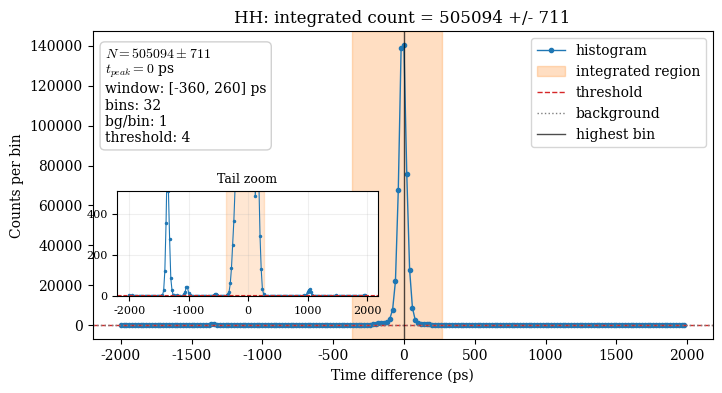

In [57]:
plot_peak_integration("HH", data_path=data_path)

In [58]:
latex_counts_table(povms)

\begin{tabular}{lccc}
\hline
Setting & $N \pm \sigma_N$ & $t_{\mathrm{peak}}$ (ps) & Window (ps) \\
\hline
HH & $505094 \pm 711$ & 0 & $[-360, 260]$ \\
HV & $412 \pm 20$ & -20 & $[-80, 60]$ \\
HD & $239783 \pm 490$ & 0 & $[-320, 240]$ \\
HL & $259253 \pm 509$ & 0 & $[-360, 240]$ \\
VH & $191 \pm 14$ & -20 & $[-60, 60]$ \\
VV & $0 \pm 1$ & -2000 & $[-2000, -2000]$ \\
VD & $64 \pm 8$ & 0 & $[-60, 60]$ \\
VL & $90 \pm 9$ & 0 & $[-40, 40]$ \\
DH & $278748 \pm 528$ & -20 & $[-340, 240]$ \\
DV & $263 \pm 16$ & 0 & $[-80, 40]$ \\
DD & $128046 \pm 358$ & -20 & $[-320, 240]$ \\
DR & $130367 \pm 361$ & 0 & $[-320, 220]$ \\
RH & $279094 \pm 528$ & -20 & $[-340, 260]$ \\
RV & $216 \pm 15$ & -20 & $[-80, 40]$ \\
RD & $126932 \pm 356$ & -20 & $[-300, 220]$ \\
RL & $142102 \pm 377$ & -20 & $[-320, 240]$ \\
\hline
\end{tabular}


'\\begin{tabular}{lccc}\n\\hline\nSetting & $N \\pm \\sigma_N$ & $t_{\\mathrm{peak}}$ (ps) & Window (ps) \\\\\n\\hline\nHH & $505094 \\pm 711$ & 0 & $[-360, 260]$ \\\\\nHV & $412 \\pm 20$ & -20 & $[-80, 60]$ \\\\\nHD & $239783 \\pm 490$ & 0 & $[-320, 240]$ \\\\\nHL & $259253 \\pm 509$ & 0 & $[-360, 240]$ \\\\\nVH & $191 \\pm 14$ & -20 & $[-60, 60]$ \\\\\nVV & $0 \\pm 1$ & -2000 & $[-2000, -2000]$ \\\\\nVD & $64 \\pm 8$ & 0 & $[-60, 60]$ \\\\\nVL & $90 \\pm 9$ & 0 & $[-40, 40]$ \\\\\nDH & $278748 \\pm 528$ & -20 & $[-340, 240]$ \\\\\nDV & $263 \\pm 16$ & 0 & $[-80, 40]$ \\\\\nDD & $128046 \\pm 358$ & -20 & $[-320, 240]$ \\\\\nDR & $130367 \\pm 361$ & 0 & $[-320, 220]$ \\\\\nRH & $279094 \\pm 528$ & -20 & $[-340, 260]$ \\\\\nRV & $216 \\pm 15$ & -20 & $[-80, 40]$ \\\\\nRD & $126932 \\pm 356$ & -20 & $[-300, 220]$ \\\\\nRL & $142102 \\pm 377$ & -20 & $[-320, 240]$ \\\\\n\\hline\n\\end{tabular}'

### Reconstruct density matrix

In [59]:
rho_naive = naive_density_matrix(povms)
metrics_naive = density_matrix_metrics(rho_naive, target=LASER)
rho_naive, metrics_naive


(array([[ 9.98807586e-01+0.00000000e+00j, -2.56477693e-02+1.28535467e-02j,
          5.16228097e-02-5.23070139e-02j, -1.13882424e-02+2.39540674e-02j],
        [-2.56477693e-02-1.28535467e-02j,  8.14717113e-04+0.00000000e+00j,
         -8.22330368e-03+6.54542147e-04j,  1.12715717e-04-1.97746872e-05j],
        [ 5.16228097e-02+5.23070139e-02j, -8.22330368e-03-6.54542147e-04j,
          3.77696526e-04+0.00000000e+00j, -6.22902647e-05-1.08760780e-05j],
        [-1.13882424e-02-2.39540674e-02j,  1.12715717e-04+1.97746872e-05j,
         -6.22902647e-05+1.08760780e-05j, -1.19601052e-18+0.00000000e+00j]]),
 {'tr_rho': array(1.),
  'tr_rho_squared': array(1.01160844),
  'fidelity': 0.9988075863610028,
  'concurrence': 0.0,
  'negativity': 0.027124380041187366,
  'entanglement_of_formation': 0.0,
  'eigenvalues': array([-9.38743711e-03, -9.98867672e-04,  4.65390719e-03,  1.00573240e+00])})

(<Figure size 1300x560 with 2 Axes>,
 (<Axes3D: title={'center': '$\\mathrm{Re}(\\rho_{\\mathrm{naive}})$'}, xlabel='$i$', ylabel='$j$', zlabel='$\\rho_{ij}$'>,
  <Axes3D: title={'center': '$\\mathrm{Im}(\\rho_{\\mathrm{naive}})$'}, xlabel='$i$', ylabel='$j$', zlabel='$\\rho_{ij}$'>))

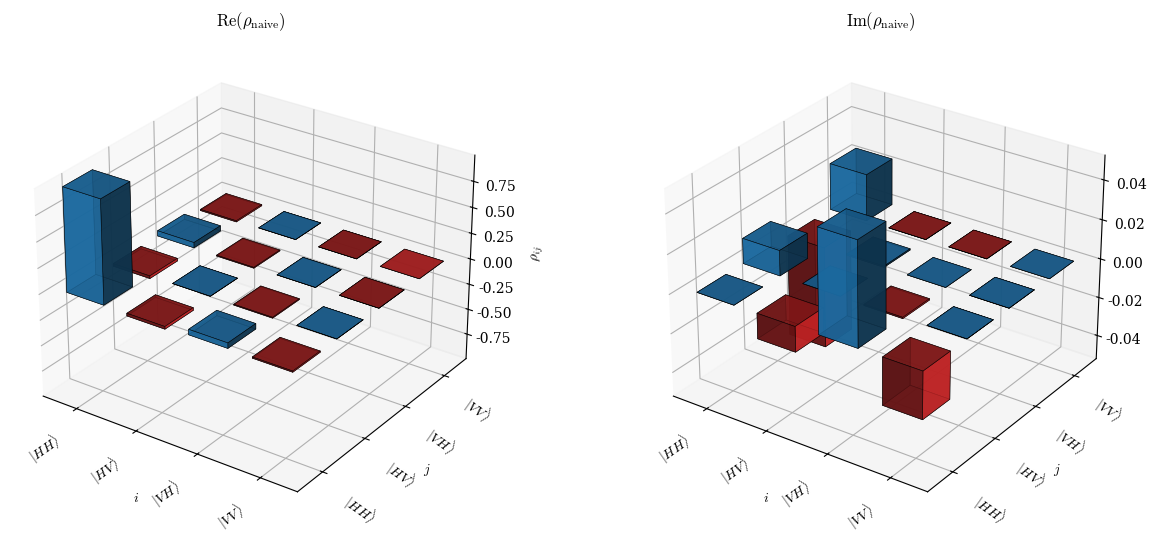

In [60]:
plot_density_matrix_3d(rho_naive)

In [61]:
latex_metrics_table(metrics_naive)

\begin{tabular}{lc}
\hline
Metric & Value \\
\hline
$\mathrm{Tr}(\rho)$ & $1$ \\
$\mathrm{Tr}(\rho^2)$ & $1.0116$ \\
$F$ & $0.99881$ \\
$C$ & $0$ \\
$\mathcal{N}$ & $0.027124$ \\
$E_F$ & $0$ \\
$\lambda_1$ & $-0.0093874$ \\
$\lambda_2$ & $-0.00099887$ \\
$\lambda_3$ & $0.0046539$ \\
$\lambda_4$ & $1.0057$ \\
\hline
\end{tabular}


'\\begin{tabular}{lc}\n\\hline\nMetric & Value \\\\\n\\hline\n$\\mathrm{Tr}(\\rho)$ & $1$ \\\\\n$\\mathrm{Tr}(\\rho^2)$ & $1.0116$ \\\\\n$F$ & $0.99881$ \\\\\n$C$ & $0$ \\\\\n$\\mathcal{N}$ & $0.027124$ \\\\\n$E_F$ & $0$ \\\\\n$\\lambda_1$ & $-0.0093874$ \\\\\n$\\lambda_2$ & $-0.00099887$ \\\\\n$\\lambda_3$ & $0.0046539$ \\\\\n$\\lambda_4$ & $1.0057$ \\\\\n\\hline\n\\end{tabular}'